# Home Credit Default Risk — End-to-End ML Pipeline

**Dataset:** [Home Credit Default Risk (Kaggle)](https://www.kaggle.com/c/home-credit-default-risk)
**Goal:** Predict whether a loan applicant will default on their repayment.
**Primary Metric:** ROC-AUC

---

## Table of Contents
1. [Setup and Imports](#1-setup-and-imports)
2. [Data Loading](#2-data-loading)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Preprocessing](#5-preprocessing)
6. [Feature Selection](#6-feature-selection)
7. [Train Test Split and Class Imbalance](#7-train-test-split-and-class-imbalance)
8. [Model Training](#8-model-training)
9. [Model Evaluation](#9-model-evaluation)
10. [Feature Importance](#10-feature-importance)

---

## Setup Instructions

1. Download the following CSV files from https://www.kaggle.com/c/home-credit-default-risk/data
   - application_train.csv
   - credit_card_balance.csv
   - bureau.csv
   - previous_application.csv
   - POS_CASH_balance.csv
   - installments_payments.csv
2. Create a folder called `data` in the same directory as this notebook
3. Place all 6 CSV files inside the `data` folder
4. Install dependencies:
   `pip install numpy pandas matplotlib seaborn scikit-learn xgboost imbalanced-learn tensorflow`
5. Run all cells top to bottom


## 1. Setup and Imports

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
import os
import gc
import pathlib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
)
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("numpy     :", np.__version__)
print("pandas    :", pd.__version__)
print("tensorflow:", tf.__version__)
print("Setup complete.")

numpy     : 2.2.5
pandas    : 2.2.3
tensorflow: 2.21.0
Setup complete.


## 2. Data Loading

In [43]:
# ── Configuration ────────────────────────────────────────────────────────────
DATA_DIR     = pathlib.Path("data")
RANDOM_STATE = 42
TEST_SIZE    = 0.20

# ── Memory Optimization ───────────────────────────────────────────────────────
def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024 ** 2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            continue
        c_min, c_max = df[col].min(), df[col].max()
        if str(col_type).startswith('int'):
            for dtype in [np.int8, np.int16, np.int32, np.int64]:
                if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                    df[col] = df[col].astype(dtype)
                    break
        else:
            for dtype in [np.float32, np.float64]:
                if c_min > np.finfo(dtype).min and c_max < np.finfo(dtype).max:
                    df[col] = df[col].astype(dtype)
                    break
    end_mem = df.memory_usage().sum() / 1024 ** 2
    if verbose:
        pct = 100 * (start_mem - end_mem) / start_mem
        print("  Memory: {:.1f} MB -> {:.1f} MB ({:.1f}% reduction)".format(
              start_mem, end_mem, pct))
    return df


def load_csv(filename):
    path = DATA_DIR / filename
    print("Loading {}...".format(filename))
    df = pd.read_csv(path)
    print("  Shape: {}".format(df.shape))
    df = reduce_mem_usage(df, verbose=True)
    return df

In [44]:
# ── Verify all required files are present ────────────────────────────────────
REQUIRED_FILES = [
    "application_train.csv",
    "credit_card_balance.csv",
    "bureau.csv",
    "previous_application.csv",
    "POS_CASH_balance.csv",
    "installments_payments.csv",
]

missing = [f for f in REQUIRED_FILES if not (DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        "Missing files in data/ folder: " + str(missing) +
        " Download from: https://www.kaggle.com/c/home-credit-default-risk/data"
        " and place them inside a folder called data next to this notebook."
    )
print("All data files found in '" + str(DATA_DIR) + "/' - ready to load.")

All data files found in 'data/' - ready to load.


## 3. Exploratory Data Analysis

In [ ]:
def dataset_summary(df, name="DataFrame"):
    print("=" * 60)
    print("  {}  |  shape: {}".format(name, df.shape))
    print("=" * 60)
    print(df.dtypes.value_counts().to_string())
    missing = (df.isnull().mean() * 100).sort_values(ascending=False)
    missing = missing[missing > 0]
    print("\n  Columns with missing data : {}".format(len(missing)))
    print("  Columns with >50% missing : {}".format((missing > 50).sum()))
    if len(missing):
        print("\n  Top 10 missing columns:")
        print(missing.head(10).to_string())

dataset_summary(train, "application_train")

  application_train  |  shape: (307511, 122)
float32    65
int8       37
object     16
int32       2
int16       2

  Columns with missing data : 67
  Columns with >50% missing : 41

  Top 10 missing columns:
COMMONAREA_AVG             69.8723
COMMONAREA_MODE            69.8723
COMMONAREA_MEDI            69.8723
NONLIVINGAPARTMENTS_MEDI   69.4330
NONLIVINGAPARTMENTS_MODE   69.4330
NONLIVINGAPARTMENTS_AVG    69.4330
FONDKAPREMONT_MODE         68.3862
LIVINGAPARTMENTS_AVG       68.3550
LIVINGAPARTMENTS_MEDI      68.3550
LIVINGAPARTMENTS_MODE      68.3550


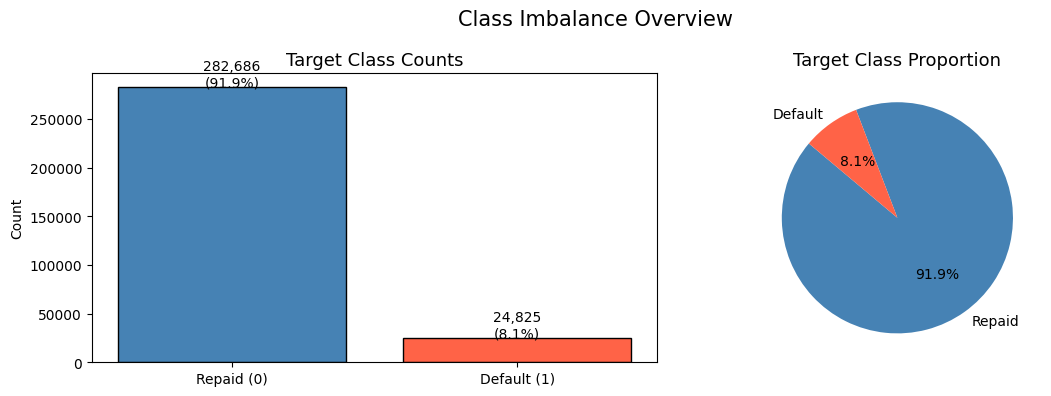

Imbalance ratio: 11.4:1


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train["TARGET"].value_counts()
axes[0].bar(["Repaid (0)", "Default (1)"], counts.values,
            color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Target Class Counts", fontsize=13)
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500,
                 "{:,}\n({:.1f}%)".format(v, v / len(train) * 100),
                 ha="center", fontsize=10)

axes[1].pie(counts.values, labels=["Repaid", "Default"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"], startangle=140)
axes[1].set_title("Target Class Proportion", fontsize=13)

plt.suptitle("Class Imbalance Overview", fontsize=15)
plt.tight_layout()
plt.show()
print("Imbalance ratio: {:.1f}:1".format(counts[0] / counts[1]))

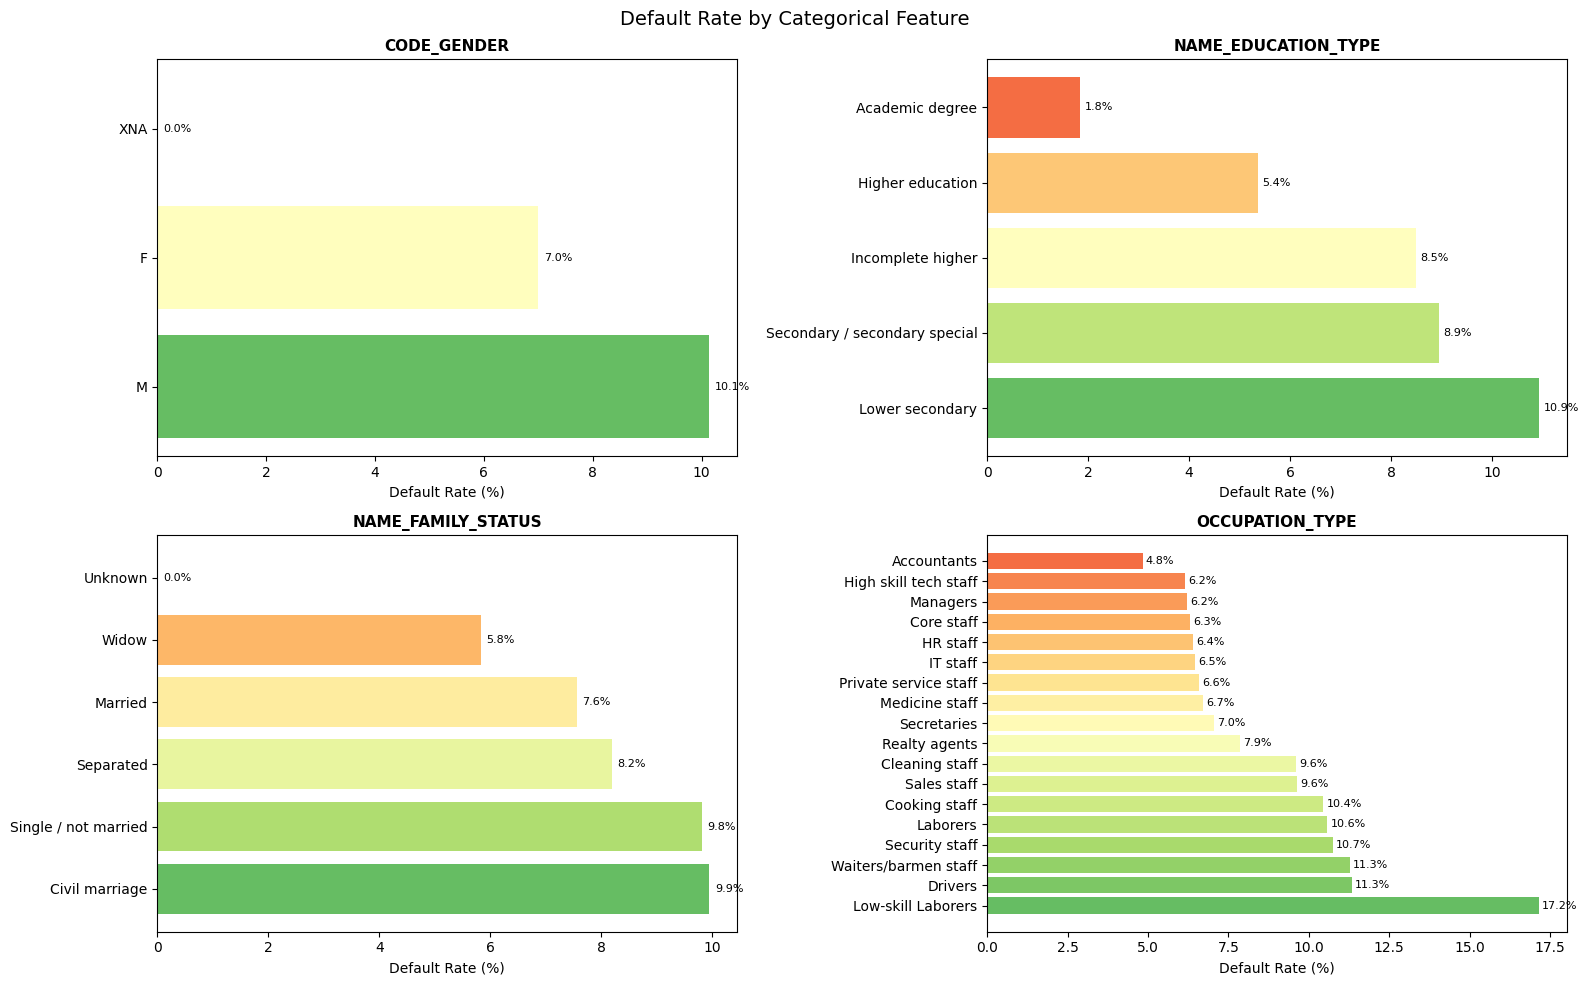

In [ ]:
categorical_cols = [
    "CODE_GENDER", "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS", "OCCUPATION_TYPE"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    default_rate = train.groupby(col)["TARGET"].mean().sort_values(ascending=False)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(default_rate)))
    bars = ax.barh(default_rate.index, default_rate.values * 100, color=colors)
    ax.set_xlabel("Default Rate (%)", fontsize=10)
    ax.set_title(col, fontsize=11, fontweight="bold")
    for bar, val in zip(bars, default_rate.values):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                "{:.1f}%".format(val * 100), va="center", fontsize=8)

plt.suptitle("Default Rate by Categorical Feature", fontsize=14)
plt.tight_layout()
plt.show()

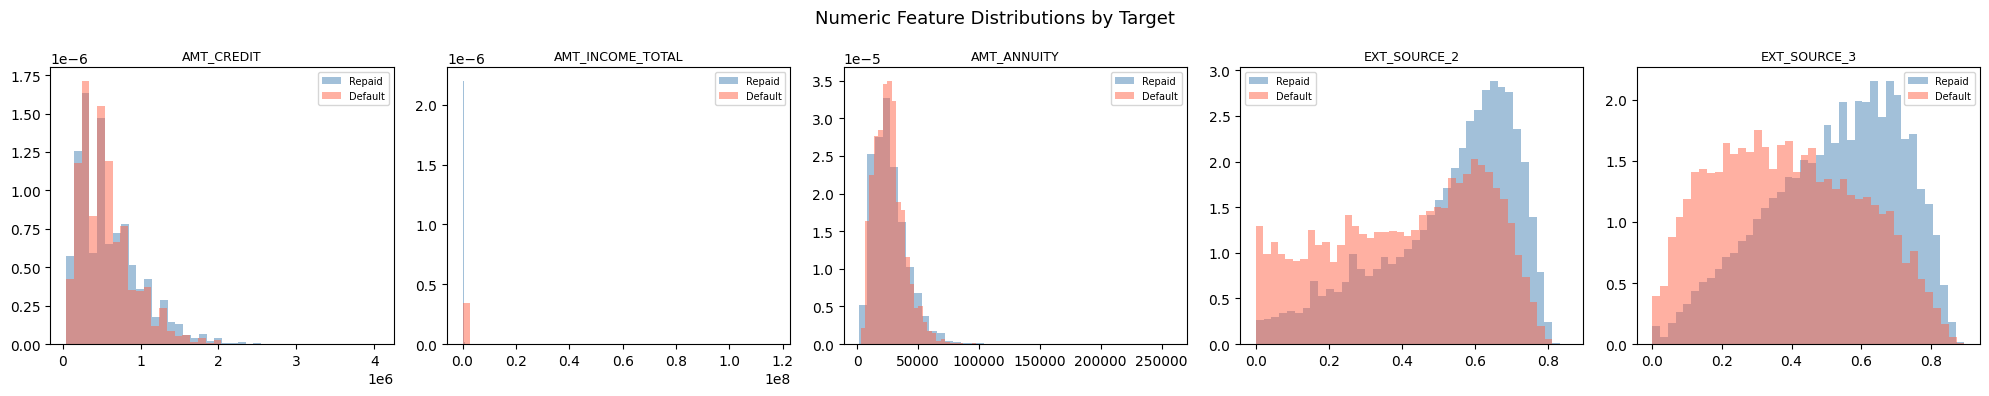

In [ ]:
num_features = ["AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_ANNUITY", "EXT_SOURCE_2", "EXT_SOURCE_3"]

fig, axes = plt.subplots(1, len(num_features), figsize=(20, 4))
for ax, feat in zip(axes, num_features):
    for target_val, color, label in [(0, "steelblue", "Repaid"), (1, "tomato", "Default")]:
        subset = train[train["TARGET"] == target_val][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Numeric Feature Distributions by Target", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
cat_df = train.select_dtypes("object")
chi2_results = []
for col in cat_df.columns:
    try:
        chi2_stat, p_val, dof, _ = stats.chi2_contingency(
            pd.crosstab(train["TARGET"], train[col])
        )
        chi2_results.append({"Feature": col, "Chi2": chi2_stat, "p-value": p_val, "DOF": dof})
    except Exception:
        pass

chi2_df = pd.DataFrame(chi2_results).sort_values("p-value")
chi2_df["Significant"] = chi2_df["p-value"] < 0.05
print("Chi-Squared Test Results:")
print(chi2_df.to_string(index=False))

Chi-Squared Test Results:
                   Feature      Chi2  p-value  DOF  Significant
         ORGANIZATION_TYPE 1609.2406   0.0000   57         True
           OCCUPATION_TYPE 1402.8468   0.0000   17         True
          NAME_INCOME_TYPE 1253.4708   0.0000    7         True
       NAME_EDUCATION_TYPE 1019.2132   0.0000    4         True
               CODE_GENDER  920.7913   0.0000    2         True
        NAME_FAMILY_STATUS  504.6941   0.0000    5         True
         NAME_HOUSING_TYPE  420.5562   0.0000    5         True
        NAME_CONTRACT_TYPE  293.1505   0.0000    1         True
              FLAG_OWN_CAR  146.6560   0.0000    1         True
        WALLSMATERIAL_MODE  139.2353   0.0000    6         True
            HOUSETYPE_MODE   27.6326   0.0000    2         True
       EMERGENCYSTATE_MODE   23.6782   0.0000    1         True
           NAME_TYPE_SUITE   32.8253   0.0000    6         True
           FLAG_OWN_REALTY   11.5758   0.0007    1         True
        FONDKA

## 4. Feature Engineering

In [ ]:
cash_balance_feats = (
    cash_balance
    .groupby("SK_ID_CURR")
    .apply(lambda x: pd.Series({
        "cc_amt_balance_total": x["AMT_BALANCE"].sum(),
        "cc_amt_balance_0_1yr": x["AMT_BALANCE"][x["MONTHS_BALANCE"] >= -12].sum(),
        "cc_amt_balance_1_2yr": x["AMT_BALANCE"][
            (x["MONTHS_BALANCE"] < -12) & (x["MONTHS_BALANCE"] >= -24)
        ].sum(),
        "cc_amt_balance_mean":  x["AMT_BALANCE"].mean(),
        "cc_months_count":      x["MONTHS_BALANCE"].count(),
    }), include_groups=False)
)
print("Credit card features shape:", cash_balance_feats.shape)

Credit card features shape: (103558, 5)


In [ ]:
bureau_num = bureau.drop(columns=["SK_ID_BUREAU"]).select_dtypes(include="number")
bureau_num["SK_ID_CURR"] = bureau["SK_ID_CURR"]

bureau_agg = bureau_num.groupby("SK_ID_CURR").agg(["mean", "max", "min", "sum"]).reset_index()
bureau_agg.columns = (
    ["SK_ID_CURR"] +
    ["bureau_{}_{}".format(col, stat) for col, stat in bureau_agg.columns[1:]]
)
bureau_agg = bureau_agg.loc[:, ~bureau_agg.columns.duplicated()]
print("Bureau features shape:", bureau_agg.shape)

Bureau features shape: (305811, 49)


In [ ]:
prev_num = previous.drop(columns=["SK_ID_PREV"]).select_dtypes(include="number")
prev_num["SK_ID_CURR"] = previous["SK_ID_CURR"]

prev_agg = prev_num.groupby("SK_ID_CURR").agg(["mean", "max", "min"]).reset_index()
prev_agg.columns = (
    ["SK_ID_CURR"] +
    ["prev_{}_{}".format(col, stat) for col, stat in prev_agg.columns[1:]]
)
prev_agg = prev_agg.loc[:, ~prev_agg.columns.duplicated()]
print("Previous application features shape:", prev_agg.shape)

Previous application features shape: (338857, 58)


In [ ]:
pos_feats = (
    pos_cash
    .groupby("SK_ID_CURR")
    .apply(lambda x: pd.Series({
        "pos_cnt_instalment_total": x["CNT_INSTALMENT"].sum(),
        "pos_cnt_instalment_0_1yr": x["CNT_INSTALMENT"][x["MONTHS_BALANCE"] >= -12].sum(),
        "pos_months_count":         x["MONTHS_BALANCE"].count(),
    }), include_groups=False)
)
print("POS cash features shape:", pos_feats.shape)

POS cash features shape: (337252, 3)


In [ ]:
inst_num = installment.drop(columns=["SK_ID_PREV"]).select_dtypes(include="number")
inst_num["SK_ID_CURR"] = installment["SK_ID_CURR"]

inst_agg = inst_num.groupby("SK_ID_CURR").agg(["mean", "sum", "max"]).reset_index()
inst_agg.columns = (
    ["SK_ID_CURR"] +
    ["inst_{}_{}".format(col, stat) for col, stat in inst_agg.columns[1:]]
)
inst_agg = inst_agg.loc[:, ~inst_agg.columns.duplicated()]
print("Installment features shape:", inst_agg.shape)

Installment features shape: (339587, 19)


In [ ]:
from functools import reduce

dfs = [train, cash_balance_feats, bureau_agg, prev_agg, pos_feats, inst_agg]

def left_join(left, right):
    return pd.merge(left, right, on="SK_ID_CURR", how="left")

data = reduce(left_join, dfs)
print("Merged dataset shape:", data.shape)

del cash_balance_feats, bureau_agg, prev_agg, pos_feats, inst_agg
gc.collect()

Merged dataset shape: (307511, 253)


0

In [ ]:
# Age and employment
data["AGE"]               = data["DAYS_BIRTH"] / -365
data["YEARS_EMPLOYED"]    = data["DAYS_EMPLOYED"].clip(upper=0) / -365
data["EMPLOYMENT_RATIO"]  = data["YEARS_EMPLOYED"] / data["AGE"].replace(0, np.nan)

# Credit and income ratios
data["DEBT_TO_INCOME"]    = data["AMT_CREDIT"]  / data["AMT_INCOME_TOTAL"].replace(0, np.nan)
data["INCOME_TO_CREDIT"]  = data["AMT_INCOME_TOTAL"] / data["AMT_CREDIT"].replace(0, np.nan)
data["ANNUITY_TO_INCOME"] = data["AMT_ANNUITY"] / data["AMT_INCOME_TOTAL"].replace(0, np.nan)
data["CREDIT_TO_GOODS"]   = data["AMT_CREDIT"]  / data["AMT_GOODS_PRICE"].replace(0, np.nan)

# External source composite scores
data["EXT_SOURCE_MEAN"]   = data[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)
data["EXT_SOURCE_MIN"]    = data[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].min(axis=1)
data["EXT_SOURCE_PROD"]   = (
    data["EXT_SOURCE_1"].fillna(1) *
    data["EXT_SOURCE_2"].fillna(1) *
    data["EXT_SOURCE_3"].fillna(1)
)

# Binary flags
data["IS_INCOME_ABOVE_MEAN"] = (data["AMT_INCOME_TOTAL"] > data["AMT_INCOME_TOTAL"].mean()).astype(int)
data["IS_RETIREE"]           = (data["NAME_INCOME_TYPE"] == "Pensioner").astype(int)
data["IS_EMPLOYED"]          = (data["NAME_INCOME_TYPE"] == "Working").astype(int)

# Consolidate document flags
flag_cols = [c for c in data.columns if c.startswith("FLAG_DOCUMENT")]
data["FLAG_DOCUMENT_SUM"] = data[flag_cols].sum(axis=1)
data.drop(columns=flag_cols, inplace=True)

print("Shape after feature engineering:", data.shape)

Shape after feature engineering: (307511, 247)


## 5. Preprocessing

In [ ]:
miss_ratio     = data.isnull().mean()
high_miss_cols = miss_ratio[miss_ratio > 0.60].index.tolist()
data.drop(columns=high_miss_cols, inplace=True)
print("Dropped {} columns with >60% missing data.".format(len(high_miss_cols)))
print("Remaining shape:", data.shape)

Dropped 31 columns with >60% missing data.
Remaining shape: (307511, 216)


In [ ]:
y     = data["TARGET"].copy()
X_raw = data.drop(columns=["SK_ID_CURR", "TARGET"])

cat_cols    = X_raw.select_dtypes(include="object").columns.tolist()
cat_imputer = SimpleImputer(strategy="most_frequent")
X_raw[cat_cols] = cat_imputer.fit_transform(X_raw[cat_cols])

X_encoded = pd.get_dummies(X_raw, columns=cat_cols, dummy_na=False)
print("Shape after one-hot encoding:", X_encoded.shape)

Shape after one-hot encoding: (307511, 335)


In [ ]:
X_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)

num_imputer = SimpleImputer(strategy="median")
X_imputed   = pd.DataFrame(
    num_imputer.fit_transform(X_encoded),
    columns=X_encoded.columns,
    index=X_encoded.index
)
print("Missing values after imputation:", X_imputed.isnull().sum().sum())

Missing values after imputation: 0


## 6. Feature Selection

In [ ]:
corr_matrix  = X_imputed.corr().abs()
upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.85)]

X_filtered = X_imputed.drop(columns=to_drop_corr)
print("Removed {} highly correlated features.".format(len(to_drop_corr)))
print("Shape after correlation filter:", X_filtered.shape)

Removed 74 highly correlated features.
Shape after correlation filter: (307511, 261)


In [ ]:
K_FEATURES = 100

selector      = SelectKBest(f_classif, k=K_FEATURES)
selector.fit(X_filtered, y)
selected_cols = X_filtered.columns[selector.get_support()].tolist()

X_selected = X_filtered[selected_cols]
print("Selected {} features via ANOVA F-test.".format(len(selected_cols)))

Selected 100 features via ANOVA F-test.


## 7. Train Test Split and Class Imbalance

In [ ]:
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_selected, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y
)

print("Train : {} | Test : {}".format(X_train_raw.shape, X_test.shape))
print("Train default rate : {:.2f}%".format(y_train_raw.mean() * 100))
print("Test  default rate : {:.2f}%".format(y_test.mean() * 100))

Train : (246008, 100) | Test : (61503, 100)
Train default rate : 8.07%
Test  default rate : 8.07%


In [ ]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print("After SMOTE — Train shape:", X_train.shape)
print("Class distribution:", pd.Series(y_train).value_counts().to_dict())

After SMOTE — Train shape: (452296, 100)
Class distribution: {0: 226148, 1: 226148}


In [ ]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Scaling complete.")

Scaling complete.


## 8. Model Training

### 8a. Random Forest

In [ ]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators      = 400,
    max_depth         = 20,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features      = "sqrt",
    bootstrap         = True,
    class_weight      = "balanced",
    random_state      = RANDOM_STATE,
    n_jobs            = -1
)
rf_model.fit(X_train, y_train)

y_pred_rf  = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest training complete.")

Training Random Forest...
Random Forest training complete.


### 8b. XGBoost

In [ ]:
print("Training XGBoost...")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    scale_pos_weight  = scale_pos_weight,
    eval_metric       = "auc",
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbosity         = 0
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost training complete.")

Training XGBoost...
XGBoost training complete.


### 8c. Neural Network

In [ ]:
def build_nn(input_dim):
    model = Sequential([
        Dense(256, activation="relu", input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer = Adam(learning_rate=1e-3),
        loss      = "binary_crossentropy",
        metrics   = ["AUC"]
    )
    return model

nn_model = build_nn(X_train_scaled.shape[1])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,865 (269.00 KB)

 Trainable params: 67,969 (265.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
print("Training Neural Network...")

callbacks = [
    EarlyStopping(monitor="val_auc", patience=10,
                  restore_best_weights=True, mode="max"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=5, min_lr=1e-6)
]

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}

history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split = 0.15,
    epochs           = 60,
    batch_size       = 512,
    class_weight     = class_weight,
    callbacks        = callbacks,
    verbose          = 1
)

y_proba_nn = nn_model.predict(X_test_scaled).flatten()
y_pred_nn  = (y_proba_nn > 0.5).astype(int)

print("Neural Network training complete.")

Training Neural Network...
Epoch 1/60
751/751 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - AUC: 0.8656 - loss: 0.4436 - val_AUC: 0.0000e+00 - val_loss: 0.2438 - learning_rate: 0.0010
Epoch 2/60
751/751 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.9086 - loss: 0.3587 - val_AUC: 0.0000e+00 - val_loss: 0.2348 - learning_rate: 0.0010
Epoch 3/60
751/751 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - AUC: 0.9197 - loss: 0.3338 - val_AUC: 0.0000e+00 - val_loss: 0.2338 - learning_rate: 0.0010
Epoch 4/60
751/751 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - AUC: 0.9258 - loss: 0.3184 - val_AUC: 0.0000e+00 - val_loss: 0.2249 - learning_rate: 0.0010
Epoch 5/60
751/751 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - AUC: 0.9309 - loss: 0.3059 - val_AUC: 0.0000e+00 - val_loss: 0.2193 - learning_rate: 0.0010
Epoch 6/60
751/751 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - AUC: 0.9345 - loss: 0.2967 - val_AUC: 0.0000e+00 - val_loss: 0.2115 - learning_rate: 0.0010
Epoch 7/60
751/751 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - AUC: 0.9374 - loss: 0.2888 - val_AUC: 0

Using keys: AUC val_AUC


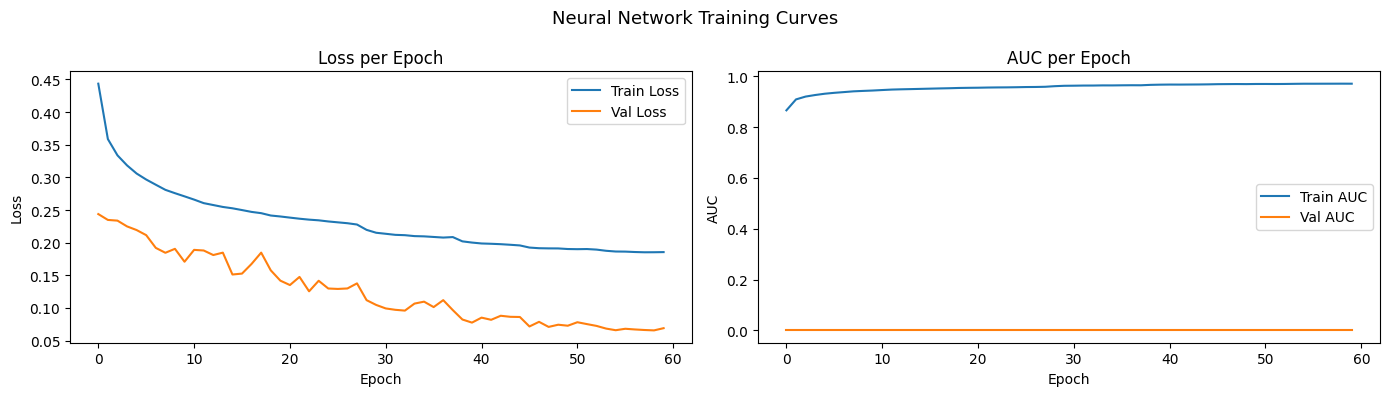

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history["loss"],     label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

train_auc_key = next((k for k in history.history if "auc" in k.lower() and "val" not in k.lower()), None)
val_auc_key   = next((k for k in history.history if "auc" in k.lower() and "val" in k.lower()), None)

print("Using keys:", train_auc_key, val_auc_key)

axes[1].plot(history.history[train_auc_key], label="Train AUC")
axes[1].plot(history.history[val_auc_key],   label="Val AUC")
axes[1].set_title("AUC per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC")
axes[1].legend()

plt.suptitle("Neural Network Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Model Evaluation

In [ ]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1"       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(y_true, y_proba), 4),
    }

results = pd.DataFrame([
    evaluate_model("Random Forest",  y_test, y_pred_rf,  y_proba_rf),
    evaluate_model("XGBoost",        y_test, y_pred_xgb, y_proba_xgb),
    evaluate_model("Neural Network", y_test, y_pred_nn,  y_proba_nn),
])
results.set_index("Model", inplace=True)
print(results.to_string())

                Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                      
Random Forest     0.9193     0.5217  0.0024 0.0048   0.7394
XGBoost           0.9194     0.5087  0.0294 0.0556   0.7702
Neural Network    0.9161     0.3617  0.0514 0.0899   0.7380


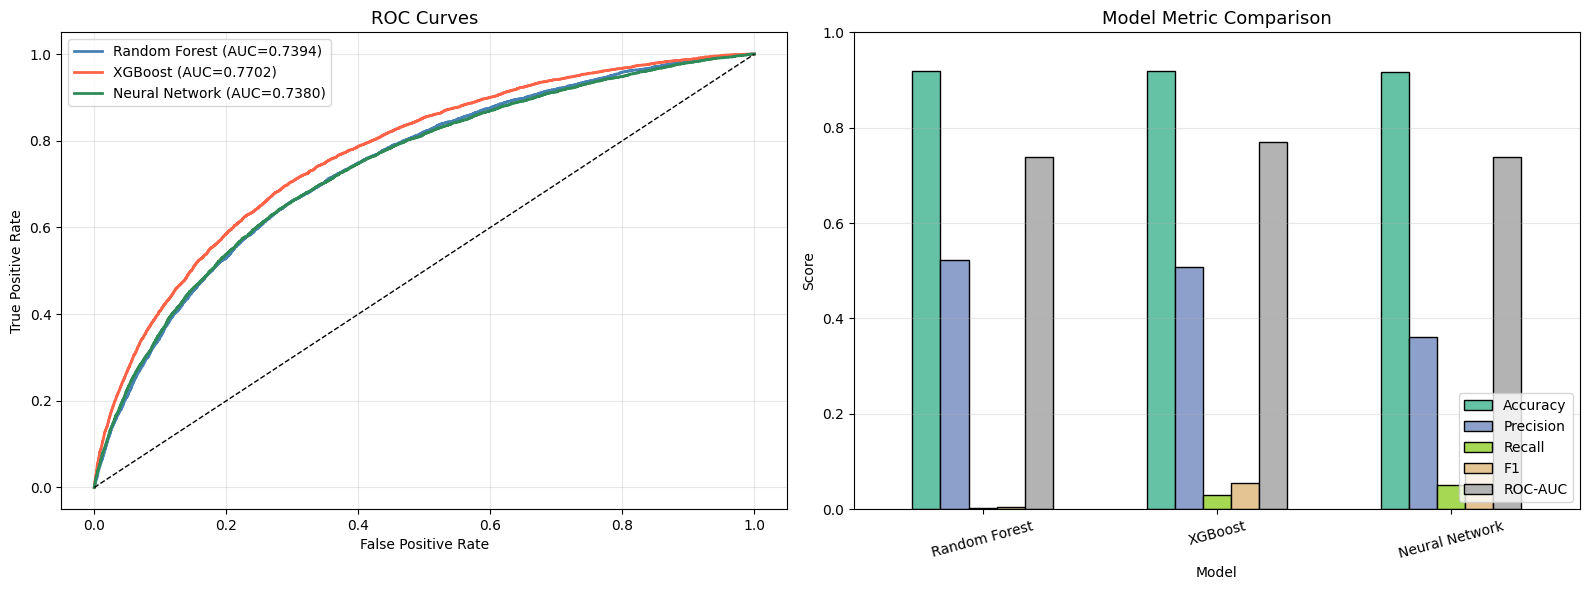

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_outputs = [
    ("Random Forest",  y_proba_rf,  "steelblue"),
    ("XGBoost",        y_proba_xgb, "tomato"),
    ("Neural Network", y_proba_nn,  "seagreen"),
]

for name, proba, color in model_outputs:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc     = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label="{} (AUC={:.4f})".format(name, roc_auc))

axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves", fontsize=13)
axes[0].legend()
axes[0].grid(alpha=0.3)

results.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="black", width=0.6)
axes[1].set_title("Model Metric Comparison", fontsize=13)
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend(loc="lower right")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

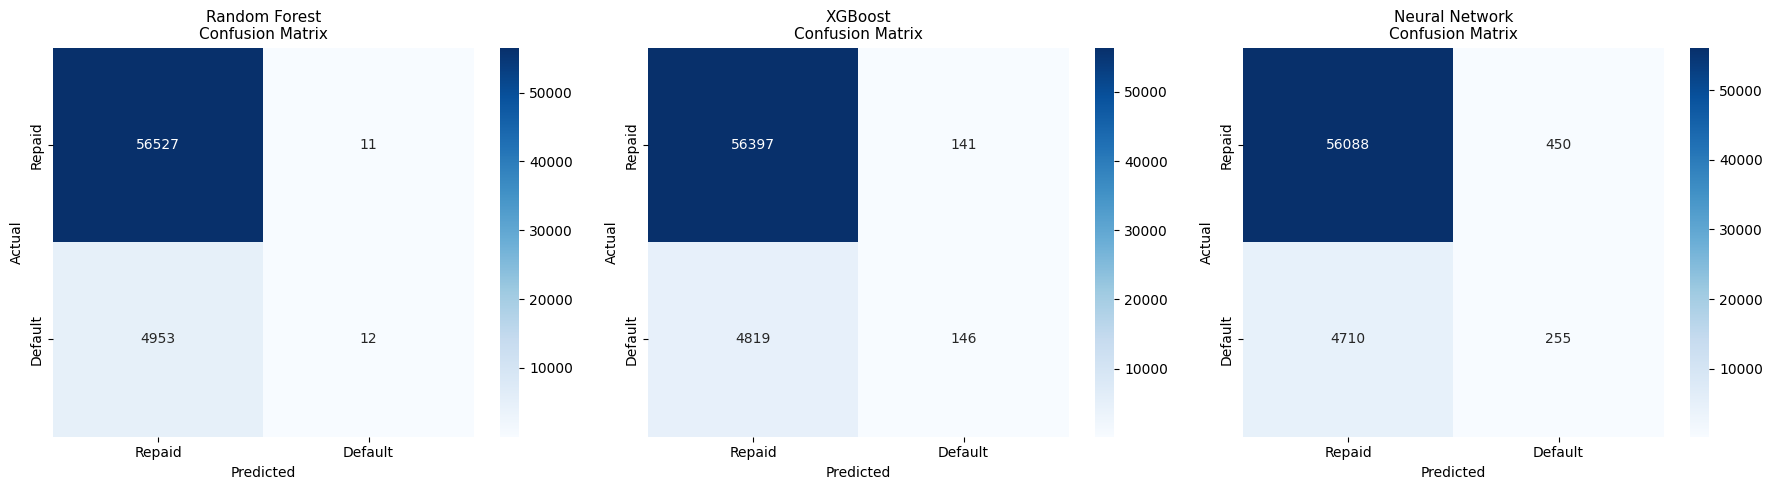

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, [
    ("Random Forest",  y_pred_rf),
    ("XGBoost",        y_pred_xgb),
    ("Neural Network", y_pred_nn),
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=["Repaid", "Default"],
                yticklabels=["Repaid", "Default"])
    ax.set_title("{}\nConfusion Matrix".format(name), fontsize=11)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

In [ ]:
for name, y_pred in [
    ("Random Forest",  y_pred_rf),
    ("XGBoost",        y_pred_xgb),
    ("Neural Network", y_pred_nn),
]:
    print("-" * 50)
    print("  {}".format(name))
    print("-" * 50)
    print(classification_report(y_test, y_pred, target_names=["Repaid", "Default"]))

--------------------------------------------------
  Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

      Repaid       0.92      1.00      0.96     56538
     Default       0.52      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.72      0.50      0.48     61503
weighted avg       0.89      0.92      0.88     61503

--------------------------------------------------
  XGBoost
--------------------------------------------------
              precision    recall  f1-score   support

      Repaid       0.92      1.00      0.96     56538
     Default       0.51      0.03      0.06      4965

    accuracy                           0.92     61503
   macro avg       0.71      0.51      0.51     61503
weighted avg       0.89      0.92      0.89     61503

--------------------------------------------------
  Neural Network
------------------------------------------------

## 10. Feature Importance

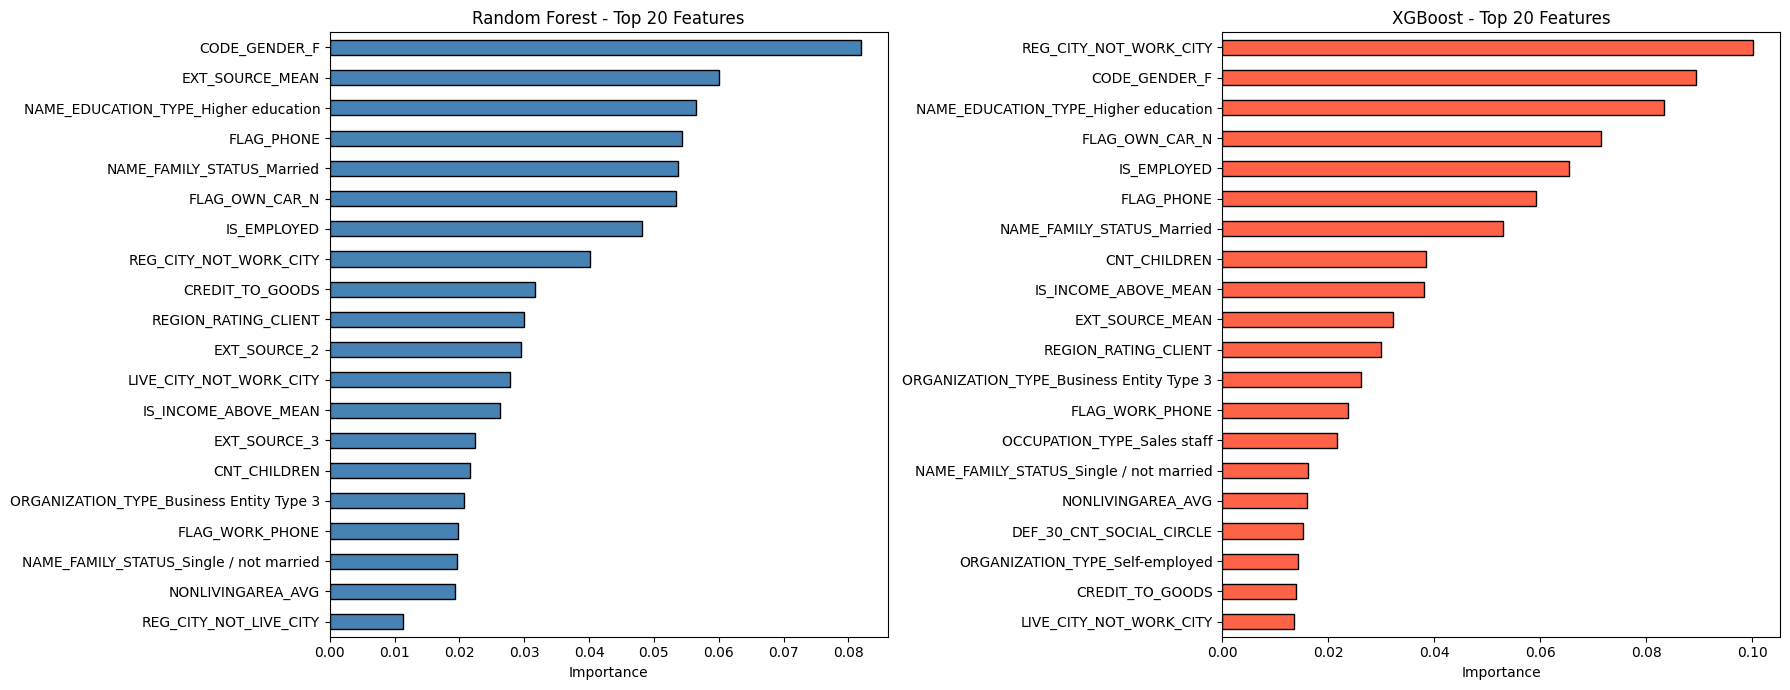

In [ ]:
rf_importances  = pd.Series(rf_model.feature_importances_,  index=selected_cols)
xgb_importances = pd.Series(xgb_model.feature_importances_, index=selected_cols)

top_rf  = rf_importances.sort_values(ascending=False).head(20)
top_xgb = xgb_importances.sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_rf.sort_values().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Random Forest - Top 20 Features", fontsize=12)
axes[0].set_xlabel("Importance")

top_xgb.sort_values().plot(kind="barh", ax=axes[1], color="tomato", edgecolor="black")
axes[1].set_title("XGBoost - Top 20 Features", fontsize=12)
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [ ]:
top10 = top_xgb.head(10).reset_index()
top10.columns = ["Feature", "XGBoost Importance"]
top10["RF Importance"] = top10["Feature"].map(rf_importances).round(4)
top10["XGBoost Importance"] = top10["XGBoost Importance"].round(4)
print("Top 10 Features by XGBoost Importance:")
print(top10.to_string(index=False))

Top 10 Features by XGBoost Importance:
                             Feature  XGBoost Importance  RF Importance
              REG_CITY_NOT_WORK_CITY              0.1002         0.0401
                       CODE_GENDER_F              0.0894         0.0819
NAME_EDUCATION_TYPE_Higher education              0.0834         0.0565
                      FLAG_OWN_CAR_N              0.0714         0.0535
                         IS_EMPLOYED              0.0655         0.0481
                          FLAG_PHONE              0.0592         0.0544
          NAME_FAMILY_STATUS_Married              0.0530         0.0537
                        CNT_CHILDREN              0.0384         0.0216
                IS_INCOME_ABOVE_MEAN              0.0381         0.0262
                     EXT_SOURCE_MEAN              0.0321         0.0601
